## 경로 설정 (레포 공통)

이 셀은 레포 어디에서 노트북을 열어도 `data/` 폴더를 자동으로 찾아 **상대경로 기반**으로 경로를 지정한다.
- `data/raw` 원자료 → `data/interim` 중간 자료 → `data/processed` 최종본, 그림·표는 `outputs/`에 저장한다.
- 노트북은 레포 안 어느 위치에서 실행해도 되지만, 레포 폴더 구조(`data/`, `src/`, `outputs/`)를 바꾸지 않아야 한다.

In [1]:
from pathlib import Path
ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "data" / "raw").exists())
RAW = ROOT / "data" / "raw"
INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"
for _d in (INTERIM, PROCESSED, FIG_DIR, TAB_DIR):
    _d.mkdir(parents=True, exist_ok=True)
print("프로젝트 루트 폴더:", ROOT.name)

프로젝트 루트 폴더: BAF-26-2-finance_2


# 선형성 확인 (노출도 구간별)

## 목적

`Post×노출도`가 선형관계라는 가정 — 노출도 낮은/높은 구간에서 효과가 다르게 나타나는 비선형일 수 있는지, 노출도를 구간(사분위)으로 나눠서 가볍게 확인한다.

**가벼운 확인 수준**(우선순위 낮음으로 분류된 항목) — 정식 비선형 모형(스플라인 등)까지는 안 하고, 사분위별 평균 ICR 추이만 본다.


## 1. 데이터 로드

In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

for f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "Pretendard", "Noto Sans CJK KR"]:
    try:
        mpl.font_manager.findfont(f, fallback_to_default=False)
        mpl.rcParams["font.family"] = f
        break
    except Exception:
        pass
mpl.rcParams["axes.unicode_minus"] = False

BASE_MERGE = PROCESSED
p_tight = BASE_MERGE / "재무_원자재_병합패널.csv"
p_calm  = BASE_MERGE / "평시_재무_원자재_병합패널.csv"

tight = pd.read_csv(p_tight, encoding="utf-8-sig")
calm  = pd.read_csv(p_calm,  encoding="utf-8-sig")

print("긴축기:", tight.shape, "| 평시:", calm.shape)


긴축기: (240, 16) | 평시: (200, 16)


## 2. 노출도 사분위 구간별 평균 ICR

각 트랙에서 `사전노출도(%)`를 4분위(Q1~Q4)로 나누고, 사분위별·Post 전후 평균 ICR을 비교한다. 만약 관계가 선형이라면 Q1→Q4로 갈수록 "Post 전후 ICR 변화 폭"이 대체로 일정한 간격으로 커지거나 작아져야 한다. 특정 구간(예: 중간 구간)에서만 효과가 튀면 비선형 신호다.

In [3]:
def quartile_analysis(df, label):
    d = df.copy()
    d["노출도_분위"] = pd.qcut(d["사전노출도(%)"], 4, labels=["Q1(최저)", "Q2", "Q3", "Q4(최고)"])

    summary = (
        d.groupby(["노출도_분위", "Post"])["ICR"]
        .mean()
        .unstack()
        .rename(columns={0: "Post=0 평균ICR", 1: "Post=1 평균ICR"})
    )
    summary["변화(Post1-Post0)"] = summary["Post=1 평균ICR"] - summary["Post=0 평균ICR"]

    range_table = (
        d.groupby("노출도_분위")["사전노출도(%)"]
        .agg(["min", "max", "count"])
        .rename(columns={"min": "구간최소", "max": "구간최대", "count": "업종x연도 관측수"})
    )

    print(f"=== {label} — 노출도 구간 범위 ===")
    display(range_table.round(2))
    print(f"=== {label} — 구간별 Post 전후 평균 ICR ===")
    display(summary.round(2))
    return summary

sum_tight = quartile_analysis(tight, "긴축기")


=== 긴축기 — 노출도 구간 범위 ===


,구간최소,구간최대,업종x연도 관측수
노출도_분위,,,
Q1(최저),2.1200,6.2400,60
Q2,6.4400,9.5700,60
Q3,9.7500,12.3200,60
Q4(최고),12.8400,21.4400,60


=== 긴축기 — 구간별 Post 전후 평균 ICR ===


Post,Post=0 평균ICR,Post=1 평균ICR,변화(Post1-Post0)
노출도_분위,,,
Q1(최저),"2,141.3700","1,538.4700",-602.9000
Q2,628.0600,545.4900,-82.5700
Q3,397.2600,328.5200,-68.7400
Q4(최고),414.4600,321.8100,-92.6500


In [4]:
sum_calm = quartile_analysis(calm, "평시")


=== 평시 — 노출도 구간 범위 ===


,구간최소,구간최대,업종x연도 관측수
노출도_분위,,,
Q1(최저),2.1700,6.8300,50
Q2,6.8300,10.6800,50
Q3,10.8000,12.8700,50
Q4(최고),14.3600,21.9700,50


=== 평시 — 구간별 Post 전후 평균 ICR ===


Post,Post=0 평균ICR,Post=1 평균ICR,변화(Post1-Post0)
노출도_분위,,,
Q1(최저),"3,540.0300","1,829.1700","-1,710.8600"
Q2,612.6500,333.9800,-278.6700
Q3,660.3200,537.1400,-123.1900
Q4(최고),326.6700,302.3900,-24.2800


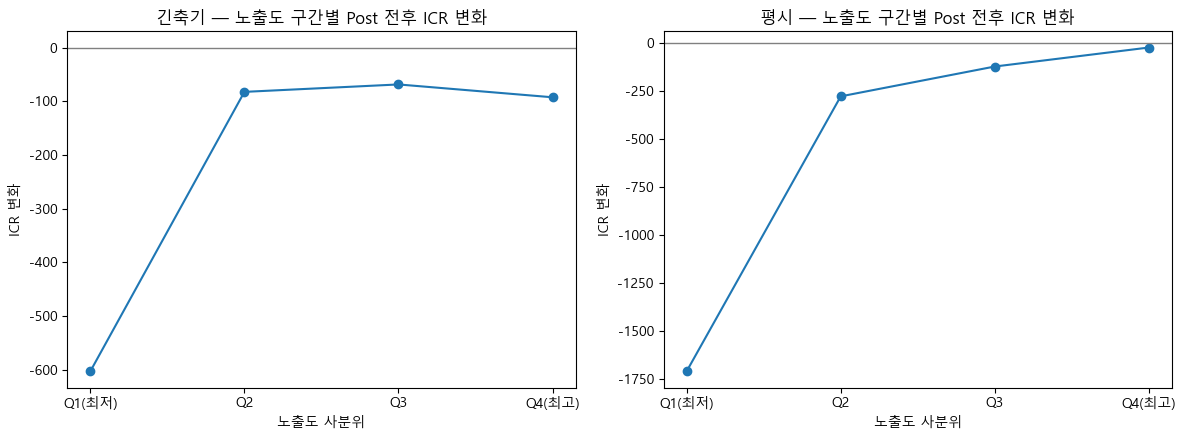

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, summary, label in zip(axes, [sum_tight, sum_calm], ["긴축기", "평시"]):
    ax.plot(summary.index.astype(str), summary["변화(Post1-Post0)"], marker="o")
    ax.axhline(0, linewidth=1, color="grey")
    ax.set_title(f"{label} — 노출도 구간별 Post 전후 ICR 변화")
    ax.set_xlabel("노출도 사분위")
    ax.set_ylabel("ICR 변화")
plt.tight_layout()
plt.show()


### 해석

Q1(노출도가 제일 낮은 업종들)의 변화가 유독 크다 — 긴축기 -602.90, 평시 -1710.86. Q2~Q4는 그에 비하면 다 작다(긴축기 -68~-93, 평시 -24~-279). 이것만 보면 "노출도 낮을수록 Post 이후 ICR이 훨씬 크게 떨어진다"는 꽤 강한 비선형처럼 보이는데, 그대로 믿기는 어렵다.

Q1엔 하필 담배·반도체·디스플레이·통신기기처럼 계속 이상치로 다뤄온 업종들이 들어있다(이 업종들이 원래 노출도가 제일 낮은 축이다). 담배는 원래 ICR 자체가 수천~수만 단위로 극단적이고, 반도체 계열은 업황따라 ICR이 몇 배씩 뛰었다 꺼졌다 한다. 그러니까 Q1의 큰 변화폭은 "노출도가 낮아서 생기는 진짜 효과"라기보다, 하필 이 그룹에 극단치 업종들이 몰려있어서 평균이 크게 흔들리는 것일 가능성이 높다.

그래서 지금 결과로 비선형이다/아니다를 확정하긴 이르다. 10번(ICR 변환)이 아직 안 정해진 상태에서 원자료 그대로 돌린 것도 원인 중 하나 — winsorize나 asinh로 바꾼 뒤에 같은 사분위 분석을 다시 해보거나, 담배·반도체 빼고 Q1을 다시 계산해보면 진짜 패턴이 좀 더 명확해질 것 같다.

## 3. 정리

- Q1에서 유독 큰 변화가 나오는데, 이게 진짜 비선형 효과인지 담배·반도체 같은 극단치 업종이 Q1에 몰려있어서 생긴 착시인지 지금 상태로는 구분이 안 됨.
- 제대로 보려면 ICR 변환(10번) 먼저 정하거나, 극단치 업종 빼고 다시 봐야 함 — 지금 결과만으로 선형성 판단을 내리지 않는다.
- 원래 이 항목이 "가벼운 확인" 수준으로 분류된 거라 여기서 더 파고들 필요는 없어 보임 — 남는 의문은 나중에 회귀 단계에서 강건성 체크(노출도 구간더미 등)로 넘기면 될 듯.
- 다음: 14번(wild cluster bootstrap).
